## Similar steps are followed for SVM linear model to thenn compare baseline and SVM models

In [16]:
from sklearn.svm import LinearSVC
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [5]:
from sklearn.model_selection import train_test_split

df = pd.read_json(
    "../data/raw/Sarcasm_Headlines_Dataset.json",
    lines=True
)

df = df[["headline", "is_sarcastic"]].dropna()
df = df.drop_duplicates(subset="headline").reset_index(drop=True)

X = df["headline"]
y = df["is_sarcastic"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [8]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=20000,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [9]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [10]:
y_val_pred_svm = svm_model.predict(X_val_tfidf)

In [14]:
svm_accuracy = accuracy_score(y_val, y_val_pred_svm)
svm_precision = precision_score(y_val, y_val_pred_svm)
svm_recall = recall_score(y_val, y_val_pred_svm)
svm_f1 = f1_score(y_val, y_val_pred_svm)

print(f"Validation Accuracy: {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1 Score: {svm_f1:.4f}")

Validation Accuracy: 0.8484
Precision: 0.8328
Recall: 0.8524
F1 Score: 0.8425


In [15]:
print(
    classification_report(
        y_val,
        y_val_pred_svm,
        target_names=["Not Sarcastic", "Sarcastic"]
    )
)

               precision    recall  f1-score   support

Not Sarcastic       0.86      0.84      0.85      2242
    Sarcastic       0.83      0.85      0.84      2033

     accuracy                           0.85      4275
    macro avg       0.85      0.85      0.85      4275
 weighted avg       0.85      0.85      0.85      4275



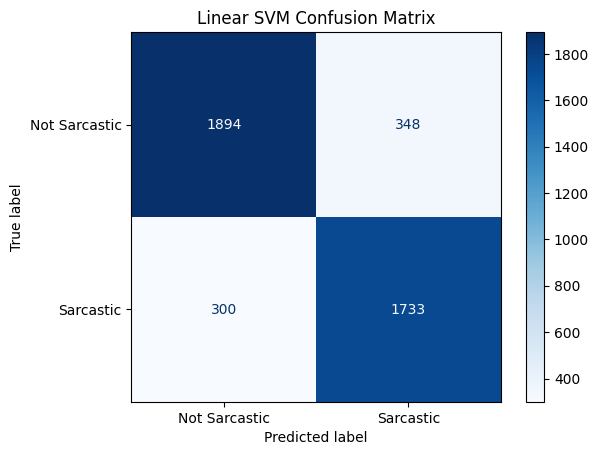

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_svm,
    display_labels=["Not Sarcastic", "Sarcastic"],
    cmap="Blues"
)

plt.title("Linear SVM Confusion Matrix")
plt.show()

that means:

1894 = True Negatives: correctly predicted Not Sarcastic

348 = False Positives: actually Not Sarcastic, but predicted Sarcastic

300 = False Negatives: actually Sarcastic, but predicted Not Sarcastic

1733 = True Positives: correctly predicted Sarcastic

## Linear SVM Model Evaluation

The Linear Support Vector Machine (SVM) model was trained using the same TF-IDF feature representation and train/validation split as the Logistic Regression baseline.

This ensures that the comparison between both classical models is fair and based on the same input features.

### Validation Results

The Linear SVM model achieved approximately:

* **Accuracy:** 0.85
* **Precision:** 0.83
* **Recall:** 0.85
* **F1-score:** 0.84 for the sarcastic class

Performance was balanced across both classes:

* **Not Sarcastic:** F1-score of 0.85
* **Sarcastic:** F1-score of 0.84

### Confusion Matrix Interpretation

The model produced the following predictions:

* **True Negatives:** 1,894
  Non-sarcastic headlines correctly classified as non-sarcastic.

* **False Positives:** 348
  Non-sarcastic headlines incorrectly classified as sarcastic.

* **False Negatives:** 300
  Sarcastic headlines incorrectly classified as non-sarcastic.

* **True Positives:** 1,733
  Sarcastic headlines correctly classified as sarcastic.

The model correctly classified the majority of examples in both classes and produced relatively similar numbers of false positives and false negatives.

### Key Observation

The Linear SVM model performs strongly on the TF-IDF representation and achieves balanced precision and recall across both sarcasm classes.

Its performance is very similar to Logistic Regression, which suggests that the TF-IDF representation captures a significant amount of useful information for this dataset. The remaining classification errors indicate that some sarcastic headlines are difficult to detect using lexical features alone and may require deeper semantic or contextual understanding.

### Conclusion

Linear SVM provides a strong classical machine learning baseline for sarcasm detection. Its performance will be compared with Logistic Regression and, later, with a transformer-based model to determine whether contextual language representations provide a meaningful improvement.
